In [1]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv(r"/kaggle/input/datasets/dgomonov/new-york-city-airbnb-open-data/AB_NYC_2019.csv")
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [4]:
df.shape

(48895, 16)

In [5]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### Remove duplicates

In [7]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

### Check for null values in each column

In [8]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [9]:
df.drop(['name', 'id', 'host_name', 'last_review'], axis=1, inplace=True, errors='ignore')

### Examining changes 

In [10]:
df.head(10)

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
5,7322,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129
6,7356,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,0.40,1,0
7,8967,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,3.47,1,220
8,7490,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,0.99,1,0
9,7549,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,1.33,4,188


### Replace the null values of reviews per month by zero

In [11]:
df.fillna({'reviews per month': 0},inplace = True)
df.reviews_per_month.isnull().sum()

np.int64(10052)

In [12]:
df.isnull().sum()
df.dropna(how='any',inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38843 entries, 0 to 48852
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_id                         38843 non-null  int64  
 1   neighbourhood_group             38843 non-null  object 
 2   neighbourhood                   38843 non-null  object 
 3   latitude                        38843 non-null  float64
 4   longitude                       38843 non-null  float64
 5   room_type                       38843 non-null  object 
 6   price                           38843 non-null  int64  
 7   minimum_nights                  38843 non-null  int64  
 8   number_of_reviews               38843 non-null  int64  
 9   reviews_per_month               38843 non-null  float64
 10  calculated_host_listings_count  38843 non-null  int64  
 11  availability_365                38843 non-null  int64  
dtypes: float64(3), int64(6), object(3)
me

In [13]:
df.describe()

,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,3.884300e+04,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000,38843.000000
mean,6.423915e+07,40.728134,-73.951148,142.317947,5.868059,29.297557,1.373221,5.164457,114.882888
std,7.588847e+07,0.054990,0.046695,196.945624,17.384784,48.186374,1.680442,26.295665,129.543636
min,2.438000e+03,40.506410,-74.244420,0.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,7.033824e+06,40.688640,-73.982470,69.000000,1.000000,3.000000,0.190000,1.000000,0.000000
50%,2.837193e+07,40.721710,-73.954800,101.000000,2.000000,9.000000,0.720000,1.000000,55.000000
75%,1.018465e+08,40.762990,-73.935020,170.000000,4.000000,33.000000,2.020000,2.000000,229.000000
max,2.738417e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [14]:
df.columns

Index(['host_id', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

# Data exploratory Ananlysis

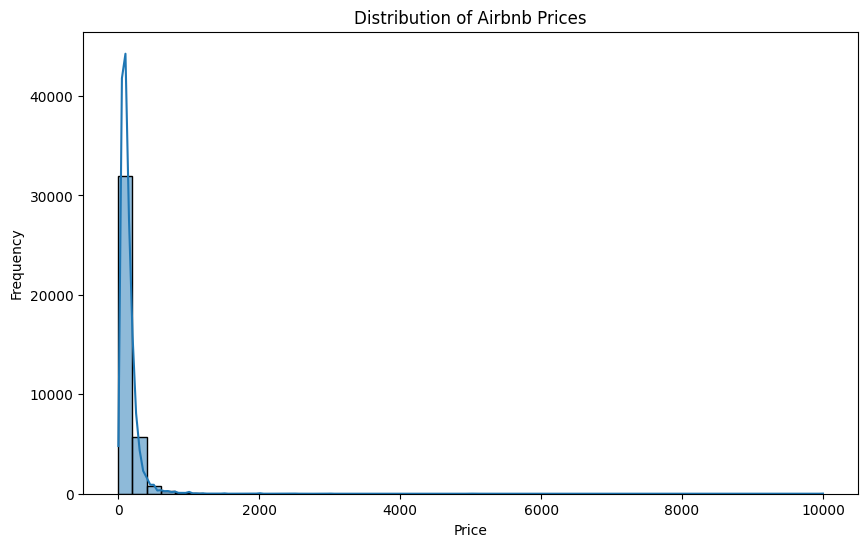

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

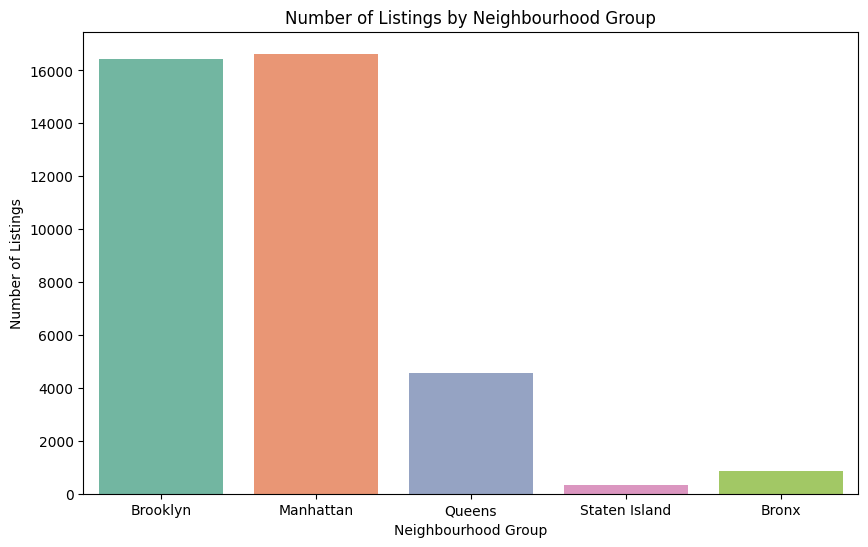

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="neighbourhood_group",
    palette="Set2"
)

plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")

plt.show()

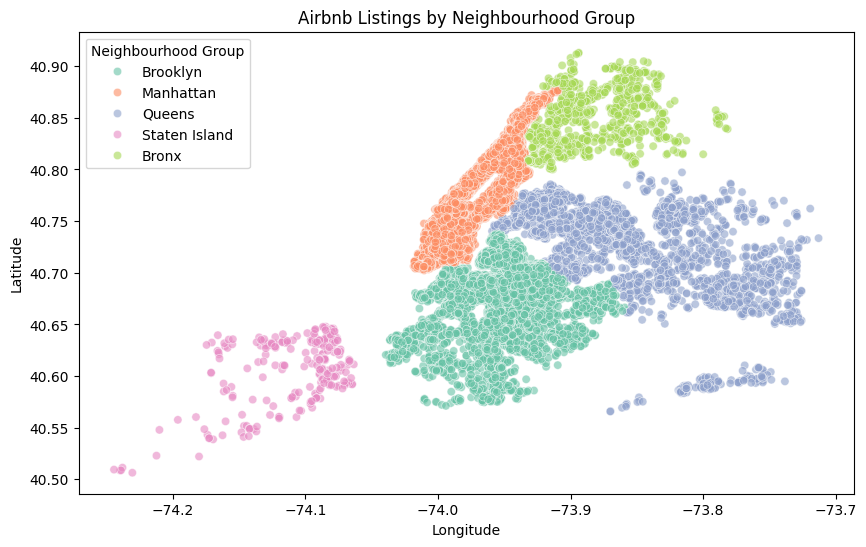

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",
    palette="Set2",
    alpha=0.6
)

plt.title("Airbnb Listings by Neighbourhood Group")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Neighbourhood Group")

plt.show()

Distribution through a Heat Map

In [18]:
import folium
from folium.plugins import HeatMap

m = folium.Map(
    location=[40.7128, -74.0060],
    zoom_start=11
)

HeatMap(
    df[['latitude', 'longitude']].dropna(),
    radius=8,
    gradient={
        0.2: 'blue',
        0.4: 'purple',
        0.6: 'orange',
        1.0: 'red'
    }
).add_to(m)

display(m)

### Lets use Kendall's Tau Correlation Matrix to show the relation between price and other values.

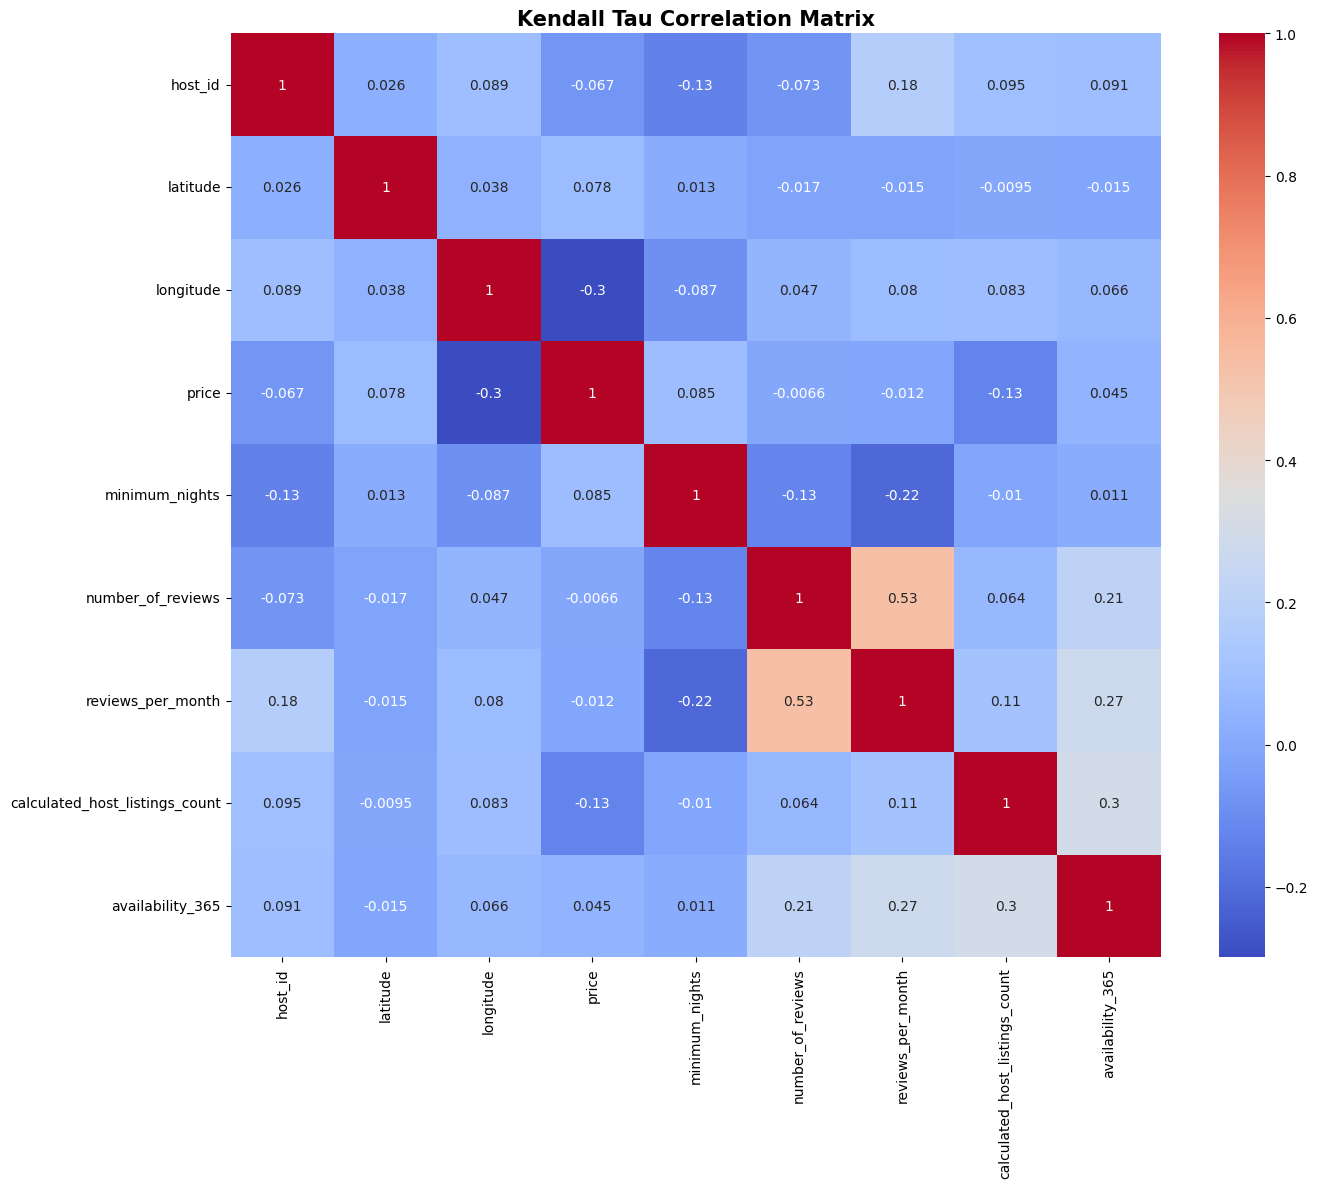

In [19]:
plt.figure(figsize=(15, 12))

corr = df.corr(method='kendall', numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Kendall Tau Correlation Matrix", size=15, weight='bold')

plt.show()

#### Relationship between price and room type using catplot

<Figure size 1000x600 with 0 Axes>

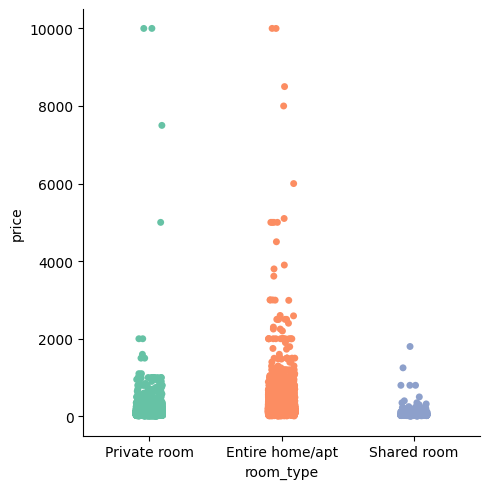

In [20]:
plt.figure(figsize=(10,6))

sns.catplot(
    x="room_type",
    y="price",
    data=df,
    palette="Set2"
)

plt.show()

#### Distribution of prices in each neighbourhood group

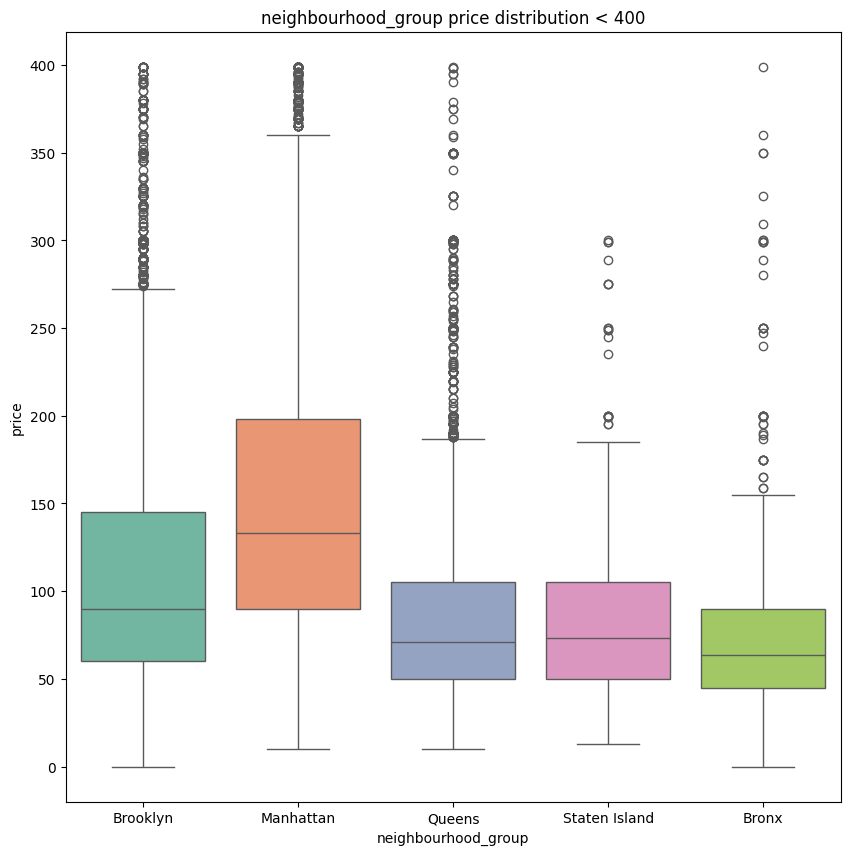

In [21]:
ng = df[df.price <400]
plt.figure(figsize=(10,10))
sns.boxplot(y="price",x ='neighbourhood_group' ,data = ng, palette="Set2")
plt.title("neighbourhood_group price distribution < 400")
plt.show()

Room types occupied by neighbourhood_group

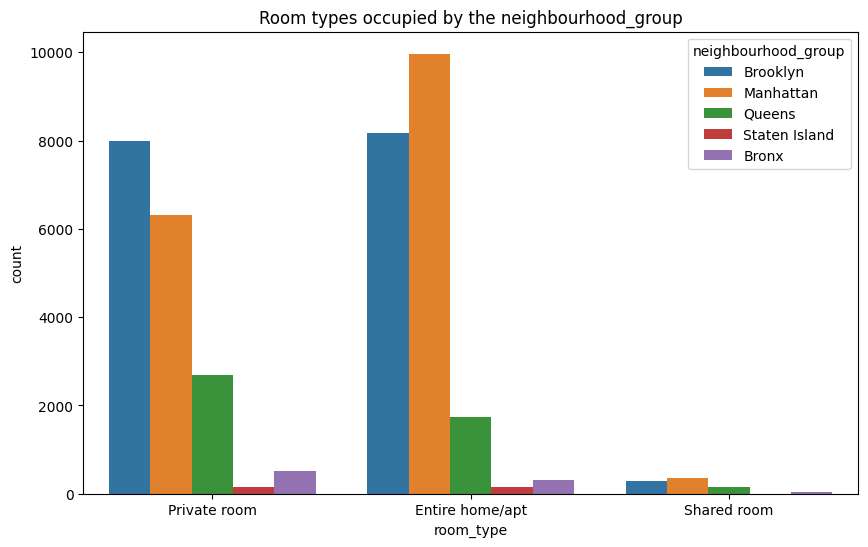

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(x = 'room_type',hue = "neighbourhood_group",data = df)
plt.title("Room types occupied by the neighbourhood_group")
plt.show()

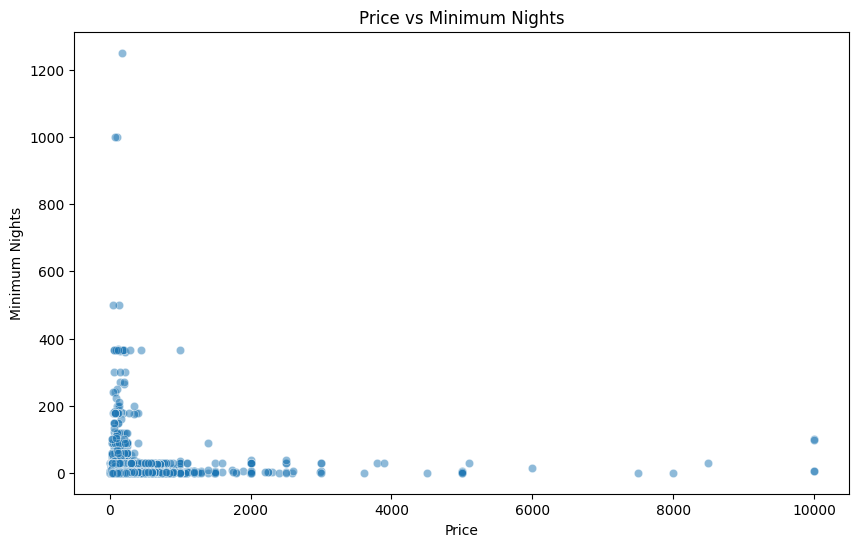

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='price',
    y='minimum_nights',
    alpha=0.5
)

plt.title("Price vs Minimum Nights")
plt.xlabel("Price")
plt.ylabel("Minimum Nights")

plt.show()

Sorting rooms according to maximum number of reviews

In [24]:
df1=df.sort_values(by=['number_of_reviews'],ascending=False).head(1000)
df1.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
11759,47621202,Queens,Jamaica,40.66730,-73.76831,Private room,47,1,629,14.58,2,333
2031,4734398,Manhattan,Harlem,40.82085,-73.94025,Private room,49,1,607,7.75,3,293
2030,4734398,Manhattan,Harlem,40.82124,-73.93838,Private room,49,1,597,7.72,3,342
2015,4734398,Manhattan,Harlem,40.82264,-73.94041,Private room,49,1,594,7.57,3,339
13495,47621202,Queens,Jamaica,40.66939,-73.76975,Private room,47,1,576,13.40,2,173


Map below showing rooms with Highest number of reviews

In [25]:
import folium
from folium.plugins import MarkerCluster

print("Rooms with the most number of reviews")

# Select top 100 rooms by reviews
top_reviews = df1.nlargest(100, 'number_of_reviews')

# New York coordinates
Lat = 40.7484
Long = -73.9857

mapdf1 = folium.Map([Lat, Long], zoom_start=11)

marker_cluster = MarkerCluster().add_to(mapdf1)

for lat, lon, reviews in zip(
    top_reviews.latitude,
    top_reviews.longitude,
    top_reviews.number_of_reviews
):
    folium.Marker(
        location=[lat, lon],
        popup=f"Number of Reviews: {reviews}"
    ).add_to(marker_cluster)

mapdf1

Rooms with the most number of reviews


Room availability

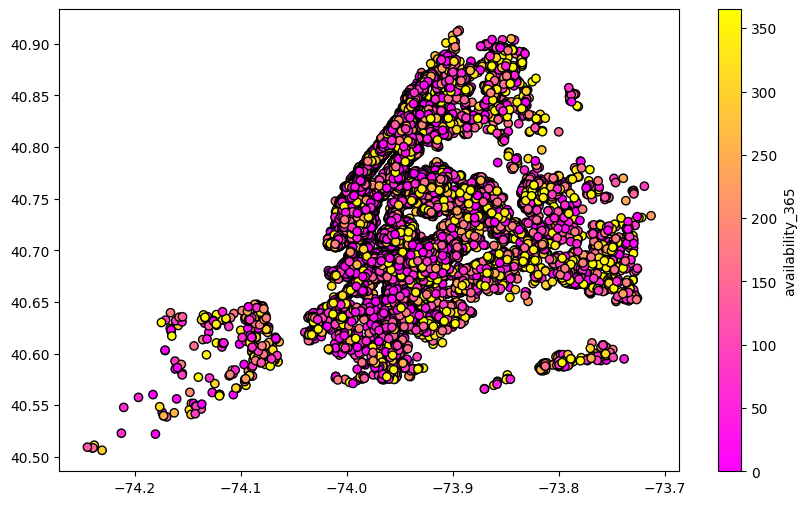

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(df.longitude, df.latitude, c=df.availability_365, cmap='spring', edgecolor='black', linewidth=1\
            , alpha=1)

cbar = plt.colorbar()
cbar.set_label('availability_365')
plt.show()

# Predictions using machine learning model

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
X = df.drop('price', axis=1)
y = df['price']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
numerical_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = X_train.select_dtypes(
    include=['object']
).columns

In [31]:
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [32]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [33]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [34]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [35]:
lgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        verbosity=-1
    ))
])

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

In [36]:
X_cat = X.copy()

categorical_cols_cat = X_cat.select_dtypes(
    include=['object']
).columns.tolist()

X_cat[categorical_cols_cat] = X_cat[categorical_cols_cat].fillna('Unknown')

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=False,
    random_seed=42
)

cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=categorical_cols_cat
)

cat_pred = cat_model.predict(X_test_cat)

In [38]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    }

In [39]:
results = []

results.append(
    evaluate_model(
        'Linear Regression',
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        'XGBoost',
        y_test,
        xgb_pred
    )
)

results.append(
    evaluate_model(
        'LightGBM',
        y_test,
        lgb_pred
    )
)

results.append(
    evaluate_model(
        'CatBoost',
        y_test_cat,
        cat_pred
    )
)

In [40]:
results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,58.968169,152.884559,0.187694
1,Random Forest,54.681694,155.182134,0.163096
2,XGBoost,54.664742,172.125743,-0.029636
3,LightGBM,56.949786,154.444991,0.171028
4,CatBoost,54.178947,153.152410,0.184846


In [41]:
predictions = pd.DataFrame({
    'Actual Price': y_test.values,
    'Linear Regression': linear_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    'LightGBM': lgb_pred,
    'CatBoost': cat_pred
})

predictions.head(10)

,Actual Price,Linear Regression,Random Forest,XGBoost,LightGBM,CatBoost
0,61,72.475828,95.670,66.263725,65.432298,75.482291
1,140,174.117860,162.470,156.248581,159.420906,168.238716
2,100,134.813888,97.210,98.533699,83.376620,93.020777
3,275,197.058727,250.470,168.473495,100.907250,167.419964
4,59,37.847630,56.880,32.699303,28.073321,106.327142
5,45,38.706717,49.300,54.524342,53.771099,56.218987
6,149,209.365896,184.960,141.969543,127.434498,158.925400
7,28,5.772488,33.590,31.693600,34.786689,36.337116
8,85,131.289681,161.555,102.585281,111.859332,112.623383
9,90,129.124544,173.570,164.968857,140.201884,145.114436


# Compare prediction error for each listing

In [42]:
predictions['LR Error'] = (
    abs(predictions['Actual Price'] -
        predictions['Linear Regression'])
)

predictions['RF Error'] = (
    abs(predictions['Actual Price'] -
        predictions['Random Forest'])
)

predictions['XGB Error'] = (
    abs(predictions['Actual Price'] -
        predictions['XGBoost'])
)

predictions['LGB Error'] = (
    abs(predictions['Actual Price'] -
        predictions['LightGBM'])
)

predictions['CAT Error'] = (
    abs(predictions['Actual Price'] -
        predictions['CatBoost'])
)

In [43]:
predictions.head(10)

,Actual Price,Linear Regression,Random Forest,XGBoost,LightGBM,CatBoost,LR Error,RF Error,XGB Error,LGB Error,CAT Error
0,61,72.475828,95.670,66.263725,65.432298,75.482291,11.475828,34.670,5.263725,4.432298,14.482291
1,140,174.117860,162.470,156.248581,159.420906,168.238716,34.117860,22.470,16.248581,19.420906,28.238716
2,100,134.813888,97.210,98.533699,83.376620,93.020777,34.813888,2.790,1.466301,16.623380,6.979223
3,275,197.058727,250.470,168.473495,100.907250,167.419964,77.941273,24.530,106.526505,174.092750,107.580036
4,59,37.847630,56.880,32.699303,28.073321,106.327142,21.152370,2.120,26.300697,30.926679,47.327142
5,45,38.706717,49.300,54.524342,53.771099,56.218987,6.293283,4.300,9.524342,8.771099,11.218987
6,149,209.365896,184.960,141.969543,127.434498,158.925400,60.365896,35.960,7.030457,21.565502,9.925400
7,28,5.772488,33.590,31.693600,34.786689,36.337116,22.227512,5.590,3.693600,6.786689,8.337116
8,85,131.289681,161.555,102.585281,111.859332,112.623383,46.289681,76.555,17.585281,26.859332,27.623383
9,90,129.124544,173.570,164.968857,140.201884,145.114436,39.124544,83.570,74.968857,50.201884,55.114436


### Compare the models overall

In [44]:
error_comparison = {
    'Linear Regression': predictions['LR Error'].mean(),
    'Random Forest': predictions['RF Error'].mean(),
    'XGBoost': predictions['XGB Error'].mean(),
    'LightGBM': predictions['LGB Error'].mean(),
    'CatBoost': predictions['CAT Error'].mean()
}

error_df = pd.DataFrame(
    error_comparison.items(),
    columns=['Model', 'Mean Absolute Error']
)

error_df

,Model,Mean Absolute Error
0,Linear Regression,58.968169
1,Random Forest,54.681694
2,XGBoost,54.664745
3,LightGBM,56.949786
4,CatBoost,54.178947


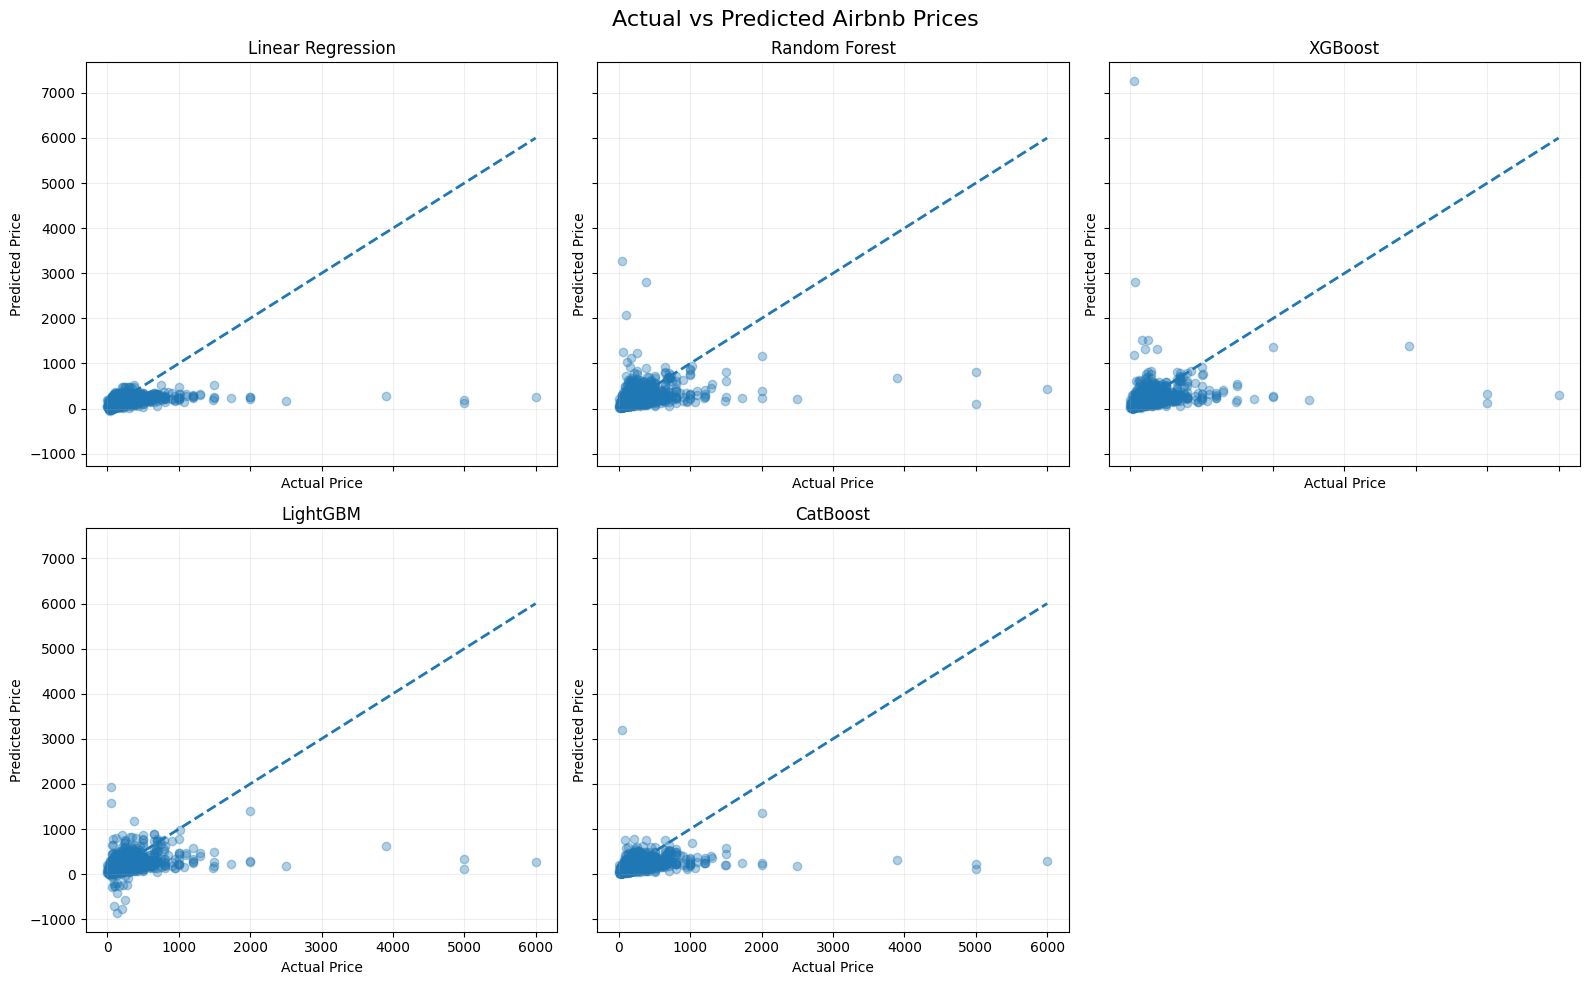

In [45]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

models = [
    ('Linear Regression', linear_pred),
    ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred),
    ('LightGBM', lgb_pred),
    ('CatBoost', cat_pred)
]

for ax, (name, pred) in zip(axes.flat, models):

    ax.scatter(
        y_test,
        pred,
        alpha=0.35
    )

    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle='--',
        linewidth=2
    )

    ax.set_title(name)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.grid(alpha=0.2)


fig.delaxes(axes[1, 2])

fig.suptitle(
    'Actual vs Predicted Airbnb Prices',
    fontsize=16
)

plt.tight_layout()
plt.show()

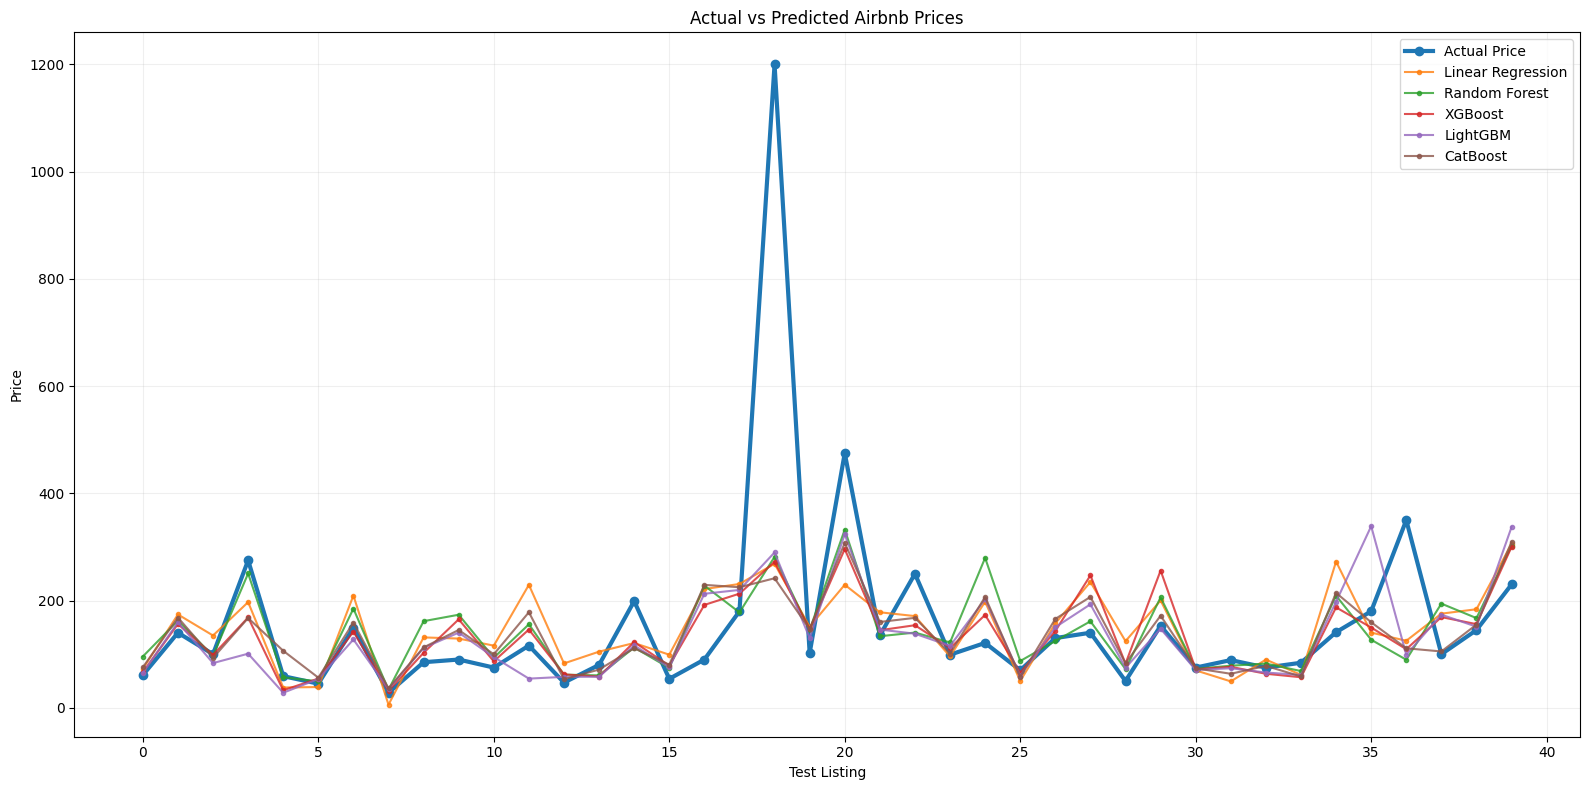

In [46]:
import matplotlib.pyplot as plt


n = 40

actual = y_test.iloc[:n].values

plt.figure(figsize=(16, 8))

plt.plot(
    range(n),
    actual,
    marker='o',
    linewidth=3,
    label='Actual Price'
)

plt.plot(
    range(n),
    linear_pred[:n],
    marker='.',
    alpha=0.8,
    label='Linear Regression'
)

plt.plot(
    range(n),
    rf_pred[:n],
    marker='.',
    alpha=0.8,
    label='Random Forest'
)

plt.plot(
    range(n),
    xgb_pred[:n],
    marker='.',
    alpha=0.8,
    label='XGBoost'
)

plt.plot(
    range(n),
    lgb_pred[:n],
    marker='.',
    alpha=0.8,
    label='LightGBM'
)

plt.plot(
    range(n),
    cat_pred[:n],
    marker='.',
    alpha=0.8,
    label='CatBoost'
)

plt.xlabel('Test Listing')
plt.ylabel('Price')
plt.title('Actual vs Predicted Airbnb Prices')
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()